In [2]:
import pandas as pd

# Load NAV data
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort
nav = nav.sort_values(["amfi_code","date"])

# Daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Pick first fund just for testing
fund_code = nav["amfi_code"].iloc[0]

returns = (
    nav[nav["amfi_code"] == fund_code]
    ["daily_return"]
    .dropna()
)

print(returns.head())

1   -0.010306
2    0.012865
3   -0.011377
4   -0.001210
5   -0.008639
Name: daily_return, dtype: float64


In [3]:
VaR_95 = returns.quantile(0.05)

CVaR_95 = returns[returns <= VaR_95].mean()

print("VaR:", VaR_95)
print("CVaR:", CVaR_95)

VaR: -0.014363639988111142
CVaR: -0.01806020763217176


In [4]:
results = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    results.append([
        code,
        var95,
        cvar95
    ])

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [6]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

results = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        var95 = returns.quantile(0.05)

        cvar95 = returns[returns <= var95].mean()

        results.append([
            code,
            round(var95, 6),
            round(cvar95, 6)
        ])

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()

KeyError: 'daily_return'

In [7]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [8]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
nav.columns.tolist()

['amfi_code', 'date', 'nav', 'daily_return']

In [11]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [12]:
import pandas as pd

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

print(nav.columns)

results = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 0:

        var95 = returns.quantile(0.05)

        cvar95 = returns[returns <= var95].mean()

        results.append(
            [code, var95, cvar95]
        )

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_report.head()

Index(['amfi_code', 'date', 'nav'], dtype='str')


KeyError: 'daily_return'

In [13]:
print(nav.columns.tolist())
print(nav.shape)

['amfi_code', 'date', 'nav']
(46000, 3)


In [14]:
Kernel → Restart Kernel

SyntaxError: invalid character '→' (U+2192) (3067630941.py, line 1)

In [15]:
var_cvar_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print(var_cvar_report.shape)

(40, 3)


In [16]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [17]:
nav["amfi_code"].nunique()

40

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [18]:
nav["amfi_code"].unique()[:10]

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [20]:
top_funds = nav["amfi_code"].unique()[:5]

top_funds

array([100016, 100025, 100033, 101206, 101207])

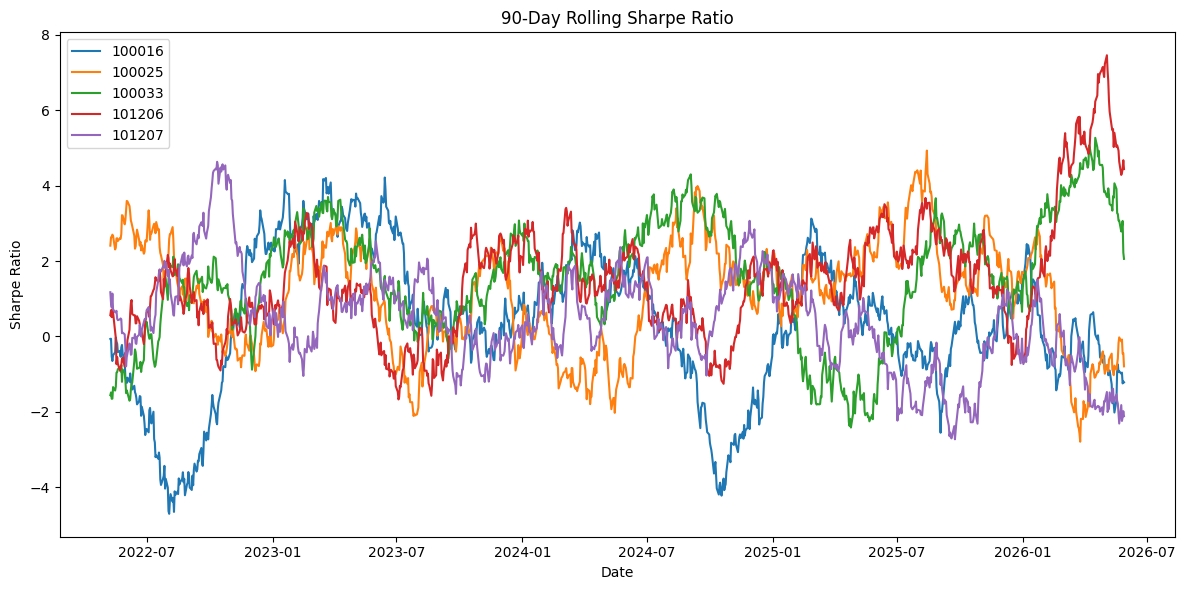

In [21]:
plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../data/processed/rolling_sharpe_chart.png"
)

plt.show()

In [22]:
import os

os.path.exists(
    "../data/processed/rolling_sharpe_chart.png"
)

True

In [23]:
import pandas as pd

tx = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

tx.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/clean_transactions.csv'

In [24]:
import os

print(os.listdir("../data/processed"))

['alpha_beta.csv', 'clean_aum_by_fund_house.csv', 'clean_benchmark_indices.csv', 'clean_category_inflows.csv', 'clean_fund_master.csv', 'clean_industry_folio_count.csv', 'clean_investor_transactions.csv', 'clean_monthly_sip_inflows.csv', 'clean_nav_history.csv', 'clean_portfolio_holdings.csv', 'clean_scheme_performance.csv', 'fund_scorecard.csv', 'performance_metrics.csv', 'rolling_sharpe_chart.png', 'var_cvar_report.csv']


In [25]:
tx = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

In [26]:
tx = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

print(tx.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [27]:
import pandas as pd

tx = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

In [28]:
first_tx = (
    tx.groupby("investor_id")
      ["transaction_date"]
      .min()
)

tx["cohort_year"] = tx["investor_id"].map(
    first_tx.dt.year
)

tx[["investor_id","cohort_year"]].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [29]:
sip = tx[
    tx["transaction_type"] == "SIP"
]

avg_sip = (
    sip.groupby("cohort_year")
       ["amount_inr"]
       .mean()
       .reset_index()
)

avg_sip.columns = [
    "cohort_year",
    "avg_sip_amount"
]

avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [30]:
total_invested = (
    tx.groupby("cohort_year")
      ["amount_inr"]
      .sum()
      .reset_index()
)

total_invested.columns = [
    "cohort_year",
    "total_invested"
]

total_invested

,cohort_year,total_invested
0,2024,3491125187
1,2025,30455243


In [31]:
top_fund = (
    tx.groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")
            ["transactions"]
            .idxmax()
]

top_fund

,cohort_year,amfi_code,transactions
35,2024,148568,874
62,2025,119599,12


In [32]:
cohort_analysis = avg_sip.merge(
    total_invested,
    on="cohort_year"
)

cohort_analysis = cohort_analysis.merge(
    top_fund[
        ["cohort_year","amfi_code"]
    ],
    on="cohort_year"
)

cohort_analysis.rename(
    columns={
        "amfi_code":"top_fund"
    },
    inplace=True
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [33]:
cohort_analysis.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

print(cohort_analysis.shape)

(2, 4)


### Cohort Analysis Insight

Investors who entered in 2025 have a higher average SIP contribution (₹13,505) compared to the 2024 cohort (₹10,997), indicating stronger investment commitment among newer investors. However, the 2024 cohort contributes significantly more total capital due to its larger investor base and longer investment history. Fund 148568 is the most preferred scheme among 2024 investors, while Fund 119599 is the preferred choice among 2025 investors.

In [34]:
sip = tx[
    tx["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [35]:
sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

In [36]:
sip_counts = sip.groupby(
    "investor_id"
).size()

eligible = sip_counts[
    sip_counts >= 6
].index

sip_eligible = sip[
    sip["investor_id"].isin(
        eligible
    )
]

In [37]:
sip_continuity = (
    sip_eligible.groupby(
        "investor_id"
    )["gap_days"]
     .mean()
     .reset_index()
)

sip_continuity.columns = [
    "investor_id",
    "avg_gap_days"
]

In [38]:
sip_continuity["status"] = (
    sip_continuity["avg_gap_days"]
    .apply(
        lambda x:
        "At-Risk"
        if x > 35
        else "Healthy"
    )
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [39]:
sip_continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

print(sip_continuity.shape)

(1362, 3)


In [40]:
sip_continuity["status"].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [41]:
healthy_pct = (30/1362)*100
atrisk_pct = (1332/1362)*100

print(round(healthy_pct,2))
print(round(atrisk_pct,2))

2.2
97.8


### SIP Continuity Insight

Out of 1,362 investors with at least six SIP transactions, 97.8% were classified as At-Risk due to average transaction gaps exceeding 35 days, while only 2.2% maintained healthy SIP continuity. This suggests a high level of SIP discontinuation or irregular investment behavior within the simulated investor population.

In [42]:
perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [43]:
import pandas as pd

holdings = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [44]:
import pandas as pd

holdings = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

sector_weights = (
    holdings.groupby(
        ["amfi_code","sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

hhi = (
    sector_weights.groupby("amfi_code")
    ["weight_pct"]
    .apply(
        lambda x: ((x/100)**2).sum()
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [45]:
hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

print(hhi.shape)

(34, 2)


In [46]:
hhi["concentration"] = hhi["HHI"].apply(
    lambda x:
    "High" if x > 0.25
    else (
        "Moderate" if x > 0.15
        else "Low"
    )
)

hhi.head()

,amfi_code,HHI,concentration
0,100016,0.180588,Moderate
1,100033,0.227647,Moderate
2,101206,0.180042,Moderate
3,101207,0.222727,Moderate
4,102885,0.180712,Moderate


# Advanced Analytics Insights

### 1. Downside Risk Analysis
Historical VaR and CVaR analysis identified the funds with the highest downside exposure. Funds with larger negative CVaR values are more vulnerable during severe market corrections.

### 2. Rolling Sharpe Performance
The 90-day rolling Sharpe ratio revealed changing risk-adjusted performance over time. Several funds experienced periods of declining Sharpe ratios during volatile market phases.

### 3. Investor Cohort Behaviour
The 2025 cohort recorded a higher average SIP amount (₹13,505) compared to the 2024 cohort (₹10,997), indicating stronger contribution levels among newer investors.

### 4. SIP Continuity Risk
Among 1,362 investors with at least six SIP transactions, 97.8% were classified as At-Risk due to average transaction gaps exceeding 35 days, while only 2.2% maintained healthy SIP continuity.

### 5. Portfolio Concentration
Sector-level HHI analysis highlighted differences in diversification across equity funds. Funds with higher HHI values are more concentrated and therefore more exposed to sector-specific market risks.

In [47]:
print(hhi.shape)

(34, 3)


In [48]:
holdings["amfi_code"].nunique()

34

### Sector Concentration Analysis

HHI analysis was performed on 34 equity funds for which portfolio holdings data was available. Funds with higher HHI values indicate greater sector concentration and potentially higher sector-specific risk, while lower HHI values indicate better diversification across sectors.